In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/DS2_C6_S5_MallCustomers_Data_Concept.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual_Income,200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending_Score,200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


#DATA CLEANING

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual_Income,0
Spending_Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Univariate Analysis

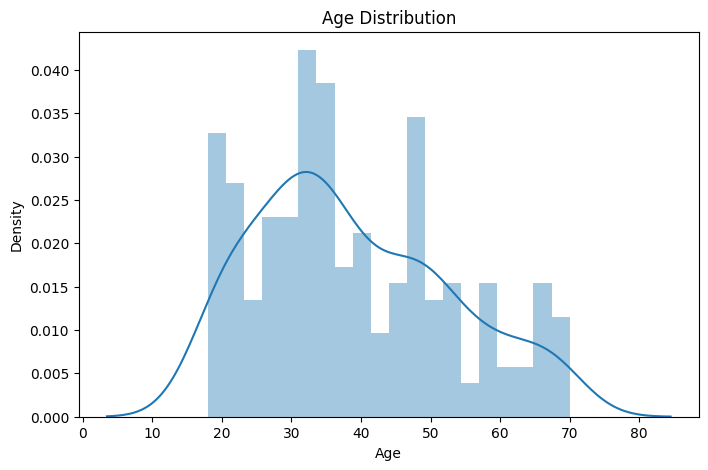

In [ ]:
plt.figure(figsize=(8,5))
sns.distplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

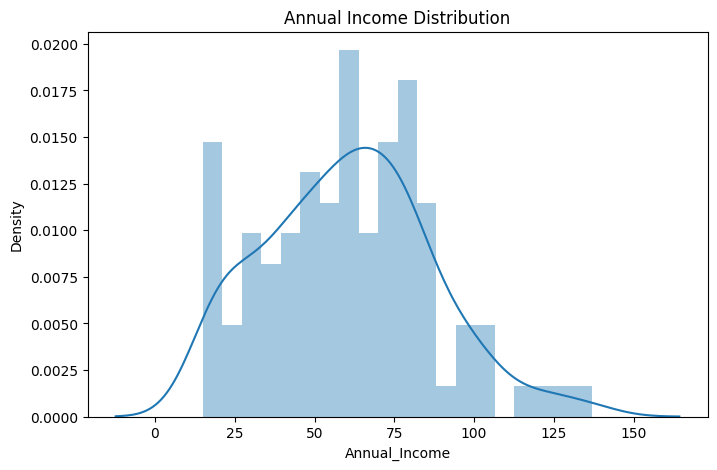

In [ ]:
plt.figure(figsize=(8,5))
sns.distplot(df['Annual_Income'], bins=20, kde=True)
plt.title('Annual Income Distribution')
plt.show()

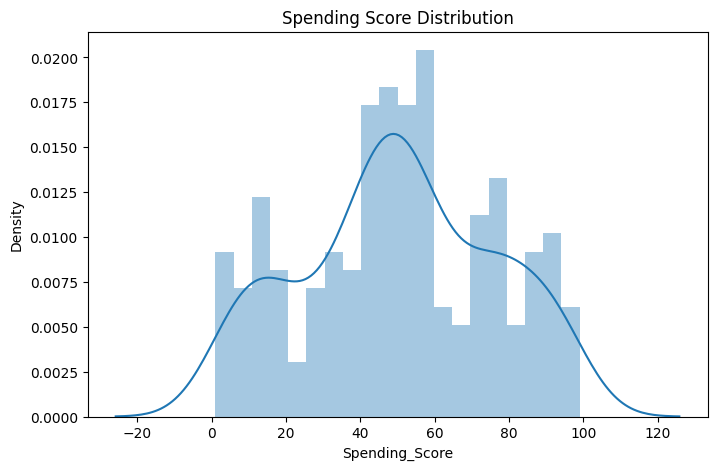

In [ ]:
plt.figure(figsize=(8,5))
sns.distplot(df['Spending_Score'], bins=20, kde=True)
plt.title('Spending Score Distribution')
plt.show()

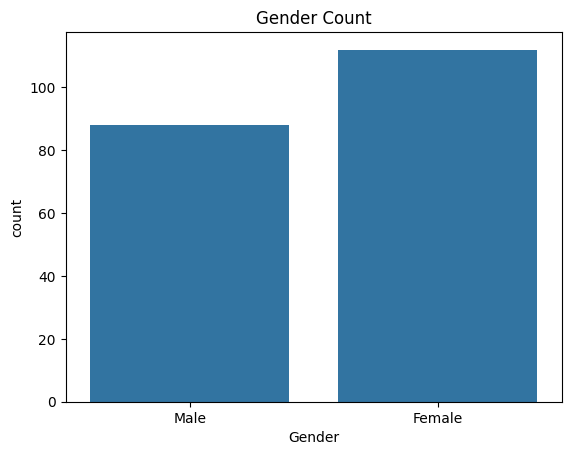

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Count')
plt.show()

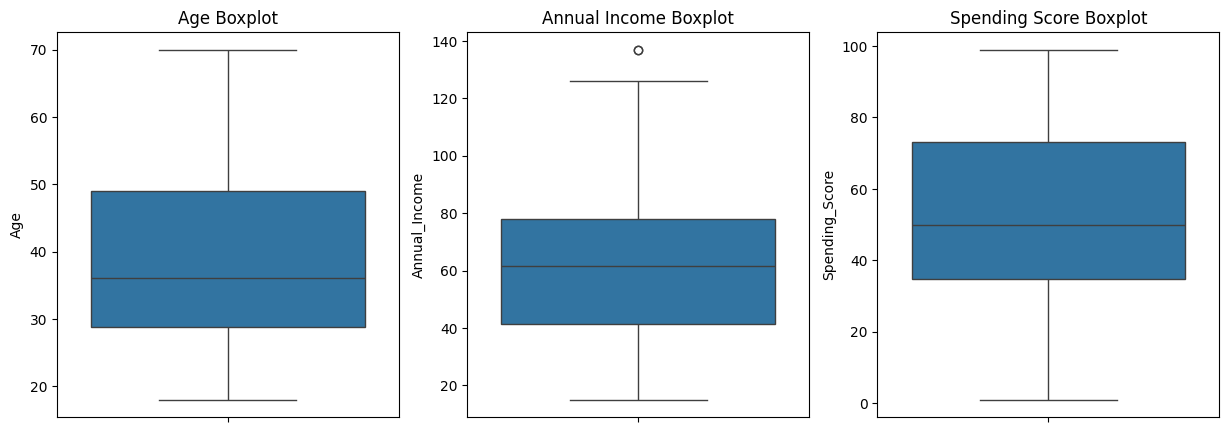

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Age'])
plt.title('Age Boxplot')

plt.subplot(1,3,2)
sns.boxplot(y=df['Annual_Income'])
plt.title('Annual Income Boxplot')

plt.subplot(1,3,3)
sns.boxplot(y=df['Spending_Score'])
plt.title('Spending Score Boxplot')

plt.show()

#Bivariate Analysis

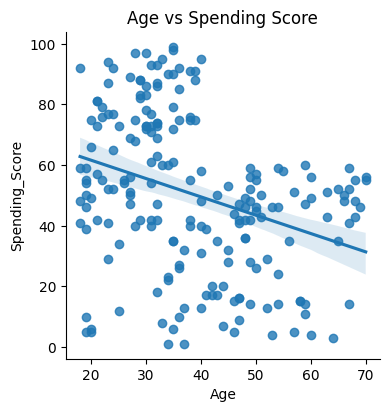

In [ ]:
sns.lmplot(x='Age', y='Spending_Score', data=df, height = 4)
plt.title('Age vs Spending Score')
plt.show()

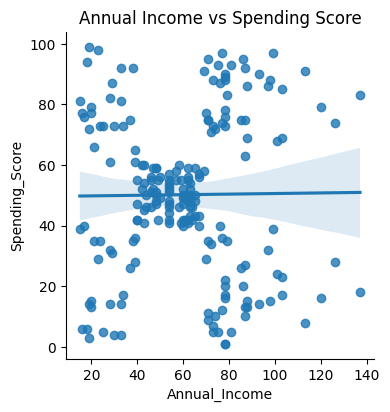

In [ ]:
sns.lmplot(x='Annual_Income', y='Spending_Score', data=df, height =4)
plt.title('Annual Income vs Spending Score')
plt.show()

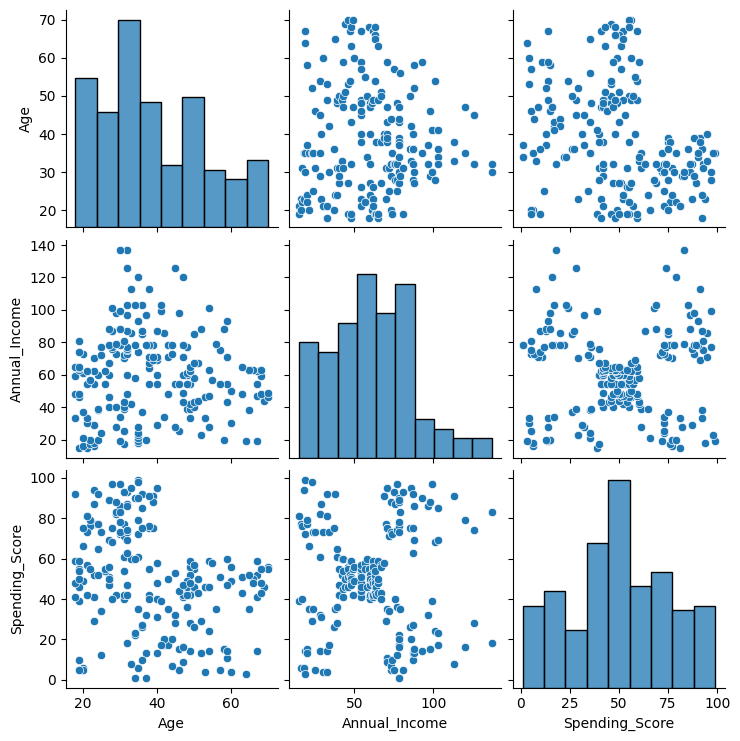

In [ ]:
sns.pairplot(df[['Age', 'Annual_Income', 'Spending_Score']])
plt.show()

#Multivariate Analysis

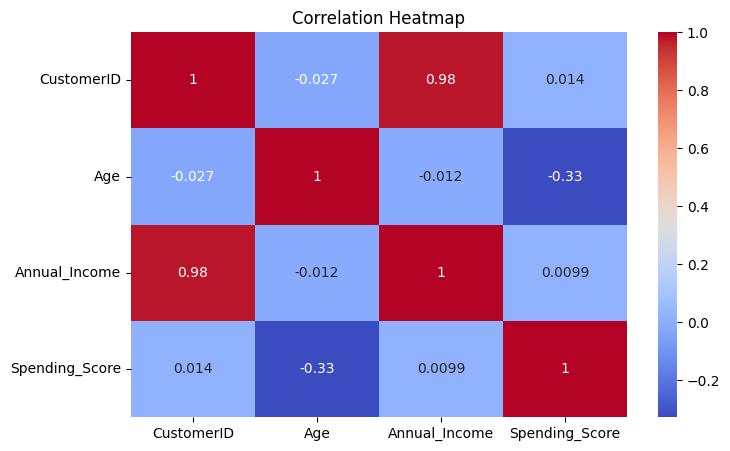

In [ ]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Select Features for Clustering

In [ ]:
X = df[['Annual_Income', 'Spending_Score']]

#Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Find Optimal Number of Clusters (Elbow Method)

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
wcss

[399.99999999999994,
 273.66888662642003,
 157.70400815035939,
 109.22822707921345,
 65.56840815571681,
 60.132874871934206,
 49.668244837367965,
 37.31912287833882,
 32.495081199100916,
 30.05932269404222]

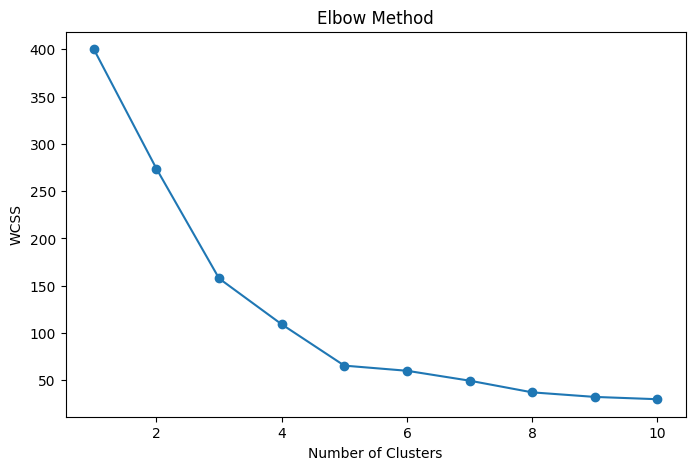

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In the elbow graph:

From 1 → 5 clusters, WCSS decreases sharply.
After 5, the graph starts flattening.
This means additional clusters are not improving the model much.

So:

K = 5 gives a good balance between:
fewer clusters
good separation

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print(score)

NameError: name 'clusters' is not defined

#Train K-Means Model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

In [ ]:
df.sample(4)

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
68,69,Male,19,48,59,0
82,83,Male,67,54,41,0
152,153,Female,44,78,20,3
168,169,Female,36,87,27,3


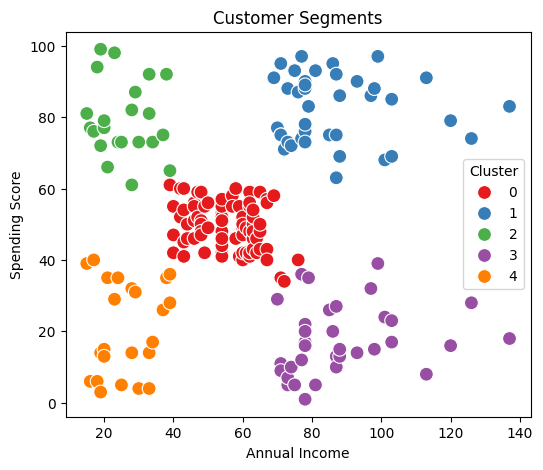

In [ ]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

#Income by Cluster

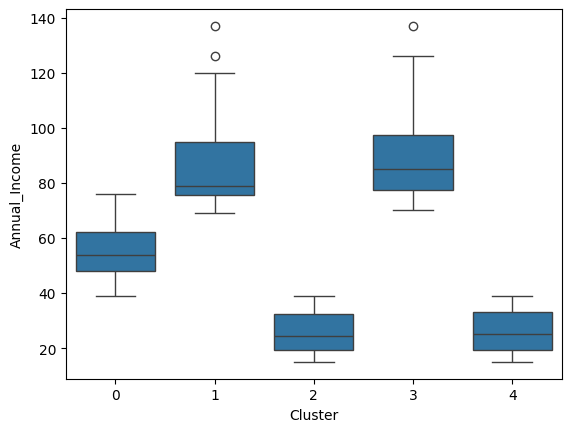

In [ ]:
sns.boxplot(x='Cluster', y='Annual_Income', data=df)
plt.show()

#Check Cluster Counts
This shows how many customers belong to each cluster.

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


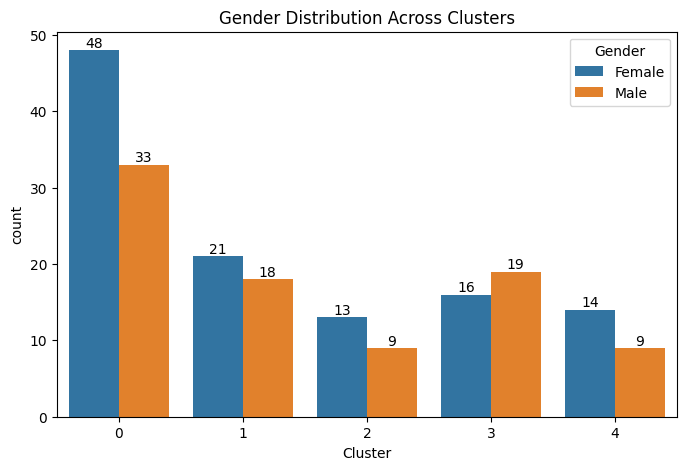

In [ ]:
#Males and females in each cluster
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Cluster',
    hue='Gender',
    data=df
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title('Gender Distribution Across Clusters')

plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual_Income,Spending_Score
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


**Final Cluster Interpretation**:

0	Medium income + Medium spending	=> Medium Customers

1	High income + High spending => Premium Customers

2	Low income + High spending =>	Young Customers

3	high income + Low spending =>	Careful Customers

4	Low income + Low spending =>	Budget Customers

#Predict New Customer Cluster

In [ ]:
new_customer = [[70, 80]]

In [ ]:
new_customer_scaled = scaler.transform(new_customer)

In [ ]:
kmeans.predict(new_customer_scaled)

array([1], dtype=int32)